<a href="https://colab.research.google.com/github/romaxod/ML-HW4-FUULXOD/blob/main/model_experiment_DeepCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Iteration 3 - Deep CNN + BatchNorm + Dropout (DeepCNN_Training)



In [3]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/api/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

Mounted at /content/drive


In [4]:
!mkdir -p data
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge -p data
!cd data && unzip -o "*.zip" >/dev/null && echo "unzipped" && ls

100% 285M/285M [00:01<00:00, 217MB/s]

unzipped
challenges-in-representation-learning-facial-expression-recognition-challenge.zip
example_submission.csv
fer2013.tar.gz
icml_face_data.csv
test.csv
train.csv


## 1. Setup

In [5]:
# --- install + imports ---
!pip -q install wandb
import os, math, numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import wandb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
torch.manual_seed(42); np.random.seed(42)

device: cuda


## 2. Dataset (Kaggle)

In [6]:

IMG_SIZE, NUM_CLASSES = 48, 7
EMOTIONS = {0:"Angry",1:"Disgust",2:"Fear",3:"Happy",4:"Sad",5:"Surprise",6:"Neutral"}
FER_MEAN, FER_STD = 0.507, 0.255

def parse_pixels(s):
    return np.fromstring(s, dtype=np.float32, sep=" ").reshape(IMG_SIZE, IMG_SIZE)

class FERDataset(Dataset):
    def __init__(self, imgs, labels, tf):
        self.imgs, self.labels, self.tf = imgs, labels, tf
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        img = self.tf(self.imgs[i].astype(np.uint8))
        if self.labels is None: return img
        return img, int(self.labels[i])

def build_tf(train, augment, normalize=True):
    t = [transforms.ToPILImage()]
    if train and augment:
        t += [transforms.RandomHorizontalFlip(),
              transforms.RandomRotation(10),
              transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0))]
    t += [transforms.ToTensor()]
    if normalize: t += [transforms.Normalize([FER_MEAN], [FER_STD])]
    return transforms.Compose(t)

def load_data(csv_path="data/icml_face_data.csv", batch_size=128, augment=False):
    df = pd.read_csv(csv_path); df.columns = [c.strip() for c in df.columns]
    def split(usage):
        sub = df[df["Usage"] == usage]
        X = np.stack([parse_pixels(p) for p in sub["pixels"].values])
        y = sub["emotion"].values.astype(np.int64)
        return X, y
    Xtr,ytr = split("Training"); Xva,yva = split("PublicTest"); Xte,yte = split("PrivateTest")
    tr = FERDataset(Xtr,ytr, build_tf(True,  augment))
    va = FERDataset(Xva,yva, build_tf(False, False))
    te = FERDataset(Xte,yte, build_tf(False, False))
    return (DataLoader(tr, batch_size, shuffle=True),
            DataLoader(va, batch_size, shuffle=False),
            DataLoader(te, batch_size, shuffle=False))

## 3. Log in to W&B

In [7]:

wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rkvit23 (rkvit23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 4. Helpers (train / eval / sanity)

In [8]:

def train_one_epoch(model, loader, opt, crit):
    model.train(); tl=correct=n=0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        opt.zero_grad(); out = model(x); loss = crit(out,y)
        loss.backward(); opt.step()
        tl += loss.item()*x.size(0); correct += (out.argmax(1)==y).sum().item(); n += x.size(0)
    return tl/n, correct/n

@torch.no_grad()
def evaluate(model, loader, crit):
    model.eval(); tl=correct=n=0; preds=[]; tgts=[]
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        out = model(x); loss = crit(out,y)
        tl += loss.item()*x.size(0); p = out.argmax(1)
        correct += (p==y).sum().item(); n += x.size(0)
        preds += p.cpu().tolist(); tgts += y.cpu().tolist()
    return tl/n, correct/n, preds, tgts

In [9]:

def sanity_checks(model):
    model = model.to(device)
    x = torch.randn(8,1,IMG_SIZE,IMG_SIZE, device=device)
    out = model(x)
    assert out.shape == (8, NUM_CLASSES), out.shape
    print("forward shape OK:", tuple(out.shape))
    y = torch.randint(0, NUM_CLASSES, (8,), device=device)
    loss = nn.CrossEntropyLoss()(model(x), y)
    print(f"loss@init = {loss.item():.3f}  (expect ~ln(7) = {math.log(7):.3f})")
    model.zero_grad(); loss.backward()
    missing = [n for n,p in model.named_parameters() if p.requires_grad and p.grad is None]
    print("params missing grad:", missing if missing else "none -> backward OK")

## 5. Model + sanity check

In [10]:

def vgg_stage(i, o, dropout=0.0):
    layers = [nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(),
              nn.Conv2d(o, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(),
              nn.MaxPool2d(2)]
    if dropout > 0: layers.append(nn.Dropout2d(dropout*0.5))
    return nn.Sequential(*layers)

class DeepCNN(nn.Module):
    """3 VGG stages + global average pool + regularized head. Depth gives capacity;
    BN + dropout + (weight decay/augmentation) give generalization."""
    def __init__(self, channels=(64,128,256), fc=256, dropout=0.4):
        super().__init__()
        c1, c2, c3 = channels
        self.features = nn.Sequential(vgg_stage(1,c1,dropout),
                                      vgg_stage(c1,c2,dropout),
                                      vgg_stage(c2,c3,dropout))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(c3, fc),
                                        nn.BatchNorm1d(fc), nn.ReLU(),
                                        nn.Dropout(dropout), nn.Linear(fc, NUM_CLASSES))
    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))

sanity_checks(DeepCNN())

forward shape OK: (8, 7)
loss@init = 2.000  (expect ~ln(7) = 1.946)
params missing grad: none -> backward OK


## 6. Training routine (W&B logging)

In [11]:

import numpy as np
HISTORY, SUMMARY, CONF = {}, [], {}

GROUP   = "DeepCNN_Training"
PROJECT = "fer2013-emotion"

def train_run(run_name, model, epochs, lr, batch_size, augment,
              weight_decay=0.0, optimizer="adam", label_smoothing=0.0, save_path=None):
    tr, va, te = load_data(batch_size=batch_size, augment=augment)
    model = model.to(device)
    n_params = sum(p.numel() for p in model.parameters())
    run = wandb.init(project=PROJECT, group=GROUP, name=run_name, reinit=True,
                     config=dict(model_type=GROUP.replace("_Training",""), config=run_name,
                                 lr=lr, batch_size=batch_size, epochs=epochs, augment=augment,
                                 weight_decay=weight_decay, optimizer=optimizer,
                                 label_smoothing=label_smoothing, n_params=n_params))
    wandb.watch(model, log="all", log_freq=100)
    opt = (torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
           if optimizer == "adam" else
           torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=weight_decay))
    crit = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    hist = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": [], "gap": []}
    best_val, best_state = 0.0, None
    for ep in range(1, epochs + 1):
        trl, tra = train_one_epoch(model, tr, opt, crit)
        val, vaa, vp, vt = evaluate(model, va, crit)
        wandb.log({"epoch": ep, "train/loss": trl, "train/acc": tra, "val/loss": val,
                   "val/acc": vaa, "overfit_gap": tra - vaa, "lr": opt.param_groups[0]["lr"]})
        for k, v in zip(hist, [tra, vaa, trl, val, tra - vaa]): hist[k].append(v)
        if vaa > best_val:
            best_val = vaa
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"ep{ep:02d}  train {tra:.3f}  val {vaa:.3f}  gap {tra-vaa:+.3f}")

    if best_state is not None: model.load_state_dict(best_state)
    tel, tea, tp, tt = evaluate(model, te, crit)
    from sklearn.metrics import f1_score, classification_report
    cls = [EMOTIONS[i] for i in range(NUM_CLASSES)]
    f1 = f1_score(tt, tp, average="macro")
    wandb.run.summary["best_val_acc"] = best_val
    wandb.run.summary["test_acc"] = tea
    wandb.run.summary["test_f1"] = f1
    rep = classification_report(tt, tp, target_names=cls, output_dict=True, zero_division=0)
    tbl = wandb.Table(columns=["class", "precision", "recall", "f1", "support"])
    for c in cls:
        r = rep[c]; tbl.add_data(c, r["precision"], r["recall"], r["f1-score"], r["support"])
    wandb.log({"val/confusion_matrix":  wandb.plot.confusion_matrix(y_true=vt, preds=vp, class_names=cls),
               "test/confusion_matrix": wandb.plot.confusion_matrix(y_true=tt, preds=tp, class_names=cls),
               "test/per_class_report": tbl})

    # --- local tracking for our own plots/tables ---
    HISTORY[run_name] = hist
    CONF[run_name] = (np.array(tt), np.array(tp))
    SUMMARY.append(dict(run=run_name, params=n_params, best_val_acc=best_val,
                        test_acc=tea, test_f1=f1, final_gap=hist["gap"][-1]))
    print(f"BEST val_acc={best_val:.4f}  TEST acc={tea:.4f}  f1={f1:.4f}")
    if save_path is not None: torch.save(model.state_dict(), save_path); print("saved ->", save_path)
    wandb.finish()
    return best_val, tea

## 7. Manual hyperparameter tuning

In [13]:
deep_configs = [
    dict(run_name="DeepCNN do=0 noaug",                       channels=(64,128,256),  fc=256, dropout=0.0, lr=1e-3, wd=0.0,  aug=False, ls=0.0, epochs=50),
    dict(run_name="DeepCNN do=0.3 noaug",                     channels=(64,128,256),  fc=256, dropout=0.3, lr=1e-3, wd=0.0,  aug=False, ls=0.0, epochs=60),
    dict(run_name="DeepCNN do=0.3 aug",                       channels=(64,128,256),  fc=256, dropout=0.3, lr=1e-3, wd=0.0,  aug=True,  ls=0.0, epochs=60),
    dict(run_name="DeepCNN do=0.4 wd=1e-4 aug",               channels=(64,128,256),  fc=256, dropout=0.4, lr=1e-3, wd=1e-4, aug=True,  ls=0.0, epochs=60),
    dict(run_name="DeepCNN do=0.4 wd=1e-4 aug ls=0.1",        channels=(64,128,256),  fc=256, dropout=0.4, lr=1e-3, wd=1e-4, aug=True,  ls=0.1, epochs=60),
    dict(run_name="DeepCNN do=0.5 lr=5e-4 wd=1e-4 aug ls=0.1",channels=(64,128,256),  fc=256, dropout=0.5, lr=5e-4, wd=1e-4, aug=True,  ls=0.1, epochs=60),
    dict(run_name="DeepCNN c=[96,192,384] do=0.4 wd=1e-4 aug ls=0.1", channels=(96,192,384), fc=384, dropout=0.4, lr=1e-3, wd=1e-4, aug=True, ls=0.1, epochs=70),
]

best_val_overall = -1.0
for c in deep_configs:
    model = DeepCNN(channels=c["channels"], fc=c["fc"], dropout=c["dropout"])
    bv, ta = train_run(c["run_name"], model, epochs=c["epochs"], lr=c["lr"], batch_size=128,
                       augment=c["aug"], weight_decay=c["wd"], label_smoothing=c["ls"])
    if bv > best_val_overall:
        best_val_overall = bv
        torch.save(model.state_dict(), "deep_cnn_best.pt")
        print(f"  >> new best: {c['run_name']} (val {bv:.4f}) -> deep_cnn_best.pt")
print("Done. best val overall:", round(best_val_overall, 4))

epoch,▁▁▂▂▃▃▄▄▅▅▅▆▆▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▅▁▄▆▅▇▆▅▆▅▅█▅▆▆▆▅
train/acc,▁▂▄▅▆▆▆▇▇▇▇▇█████
train/loss,█▇▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁
val/acc,▁▃▅▅▆▆▆▇▇▇▇▇█▇███
val/loss,█▇▅▅▃▄▃▂▂▂▂▃▁▂▂▁▁
epoch,17
lr,0.001
overfit_gap,-0.01676
train/acc,0.60653


ep01  train 0.367  val 0.422  gap -0.055
ep02  train 0.519  val 0.430  gap +0.089
ep03  train 0.579  val 0.563  gap +0.016
ep04  train 0.615  val 0.564  gap +0.051
ep05  train 0.643  val 0.568  gap +0.075
ep06  train 0.676  val 0.503  gap +0.172
ep07  train 0.706  val 0.520  gap +0.186
ep08  train 0.741  val 0.487  gap +0.255
ep09  train 0.778  val 0.578  gap +0.200
ep10  train 0.815  val 0.547  gap +0.268
ep11  train 0.852  val 0.534  gap +0.318
ep12  train 0.892  val 0.458  gap +0.434
ep13  train 0.923  val 0.577  gap +0.345
ep14  train 0.946  val 0.481  gap +0.466
ep15  train 0.958  val 0.512  gap +0.446
ep16  train 0.968  val 0.497  gap +0.471
ep17  train 0.965  val 0.565  gap +0.400
ep18  train 0.979  val 0.605  gap +0.374
ep19  train 0.980  val 0.536  gap +0.444
ep20  train 0.976  val 0.570  gap +0.406
ep21  train 0.978  val 0.457  gap +0.521
ep22  train 0.980  val 0.541  gap +0.439
ep23  train 0.981  val 0.471  gap +0.510
ep24  train 0.977  val 0.549  gap +0.428
ep25  train 0.97

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▃▂▂▂▄▄▅▅▆▇▆▇▆▆▆▇▆▇▆▆▅▆▆▇▆▆▅▆▆▆▆█▆▅▅▅▆▆▅
train/acc,▁▃▃▄▄▅▅▆▆▆▇▇████████████████████████████
train/loss,█▆▆▅▅▄▄▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▂▂▆▆▆▄▃▆▅▅▆▃▄▄▇▆▃▅▃▅▆█▇▆▄▇▇█▇▇▆▆▁▇████▄█
val/loss,▁▂▁▁▁▂▂▁▁▂▂▃▃▃▃▄▃▇▃▅▅▄▃▂▄▄▃▃▃▄▄▄▃█▃▃▃▃▄▃
best_val_acc,0.64976
epoch,50
lr,0.001
overfit_gap,0.35755


  >> new best: DeepCNN do=0 noaug (val 0.6498) -> deep_cnn_best.pt


ep01  train 0.251  val 0.299  gap -0.048
ep02  train 0.360  val 0.450  gap -0.090
ep03  train 0.463  val 0.489  gap -0.026
ep04  train 0.502  val 0.535  gap -0.033
ep05  train 0.535  val 0.516  gap +0.019
ep06  train 0.553  val 0.555  gap -0.002
ep07  train 0.572  val 0.562  gap +0.010
ep08  train 0.586  val 0.566  gap +0.020
ep09  train 0.602  val 0.596  gap +0.006
ep10  train 0.614  val 0.593  gap +0.021
ep11  train 0.625  val 0.605  gap +0.020
ep12  train 0.640  val 0.612  gap +0.028
ep13  train 0.651  val 0.581  gap +0.070
ep14  train 0.661  val 0.627  gap +0.034
ep15  train 0.674  val 0.626  gap +0.048
ep16  train 0.687  val 0.628  gap +0.059
ep17  train 0.703  val 0.632  gap +0.071
ep18  train 0.710  val 0.627  gap +0.083
ep19  train 0.723  val 0.628  gap +0.095
ep20  train 0.739  val 0.633  gap +0.106
ep21  train 0.751  val 0.644  gap +0.107
ep22  train 0.767  val 0.644  gap +0.123
ep23  train 0.779  val 0.620  gap +0.159
ep24  train 0.791  val 0.652  gap +0.139
ep25  train 0.80

epoch,▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▂▁▃▂▃▃▃▃▄▃▃▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇█▇███▇███
train/acc,▁▂▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇███████████████
train/loss,█▆▆▆▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▄▅▆▅▆▆▇▇▇▆▇▇▇▇▇▇█▇█████▇███████████████
val/loss,▆▄▃▂▃▂▂▁▂▁▁▁▁▁▁▂▂▂▂▃▅▅▅▅▅▅▅▆▆▇▇▆▇▇▆▇▇▇▇█
best_val_acc,0.65952
epoch,60
lr,0.001
overfit_gap,0.3301


  >> new best: DeepCNN do=0.3 noaug (val 0.6595) -> deep_cnn_best.pt


ep01  train 0.249  val 0.284  gap -0.036
ep02  train 0.343  val 0.379  gap -0.036
ep03  train 0.442  val 0.466  gap -0.024
ep04  train 0.475  val 0.503  gap -0.028
ep05  train 0.502  val 0.533  gap -0.031
ep06  train 0.518  val 0.542  gap -0.024
ep07  train 0.529  val 0.550  gap -0.021
ep08  train 0.548  val 0.572  gap -0.024
ep09  train 0.557  val 0.570  gap -0.013
ep10  train 0.567  val 0.590  gap -0.023
ep11  train 0.572  val 0.598  gap -0.025
ep12  train 0.582  val 0.584  gap -0.002
ep13  train 0.590  val 0.604  gap -0.014
ep14  train 0.595  val 0.616  gap -0.021
ep15  train 0.600  val 0.611  gap -0.011
ep16  train 0.608  val 0.605  gap +0.002
ep17  train 0.611  val 0.622  gap -0.011
ep18  train 0.619  val 0.624  gap -0.005
ep19  train 0.620  val 0.632  gap -0.012
ep20  train 0.626  val 0.621  gap +0.006
ep21  train 0.629  val 0.636  gap -0.006
ep22  train 0.633  val 0.635  gap -0.002
ep23  train 0.638  val 0.639  gap -0.001
ep24  train 0.644  val 0.639  gap +0.004
ep25  train 0.64

KeyboardInterrupt: 

In [14]:
# remaining DeepCNN configs — the 3 above already ran & logged. Trimmed for time, still solid.
deep_configs = [
    dict(run_name="DeepCNN do=0.4 wd=1e-4 aug ls=0.1",               channels=(64,128,256), fc=256, dropout=0.4, lr=1e-3, wd=1e-4, aug=True, ls=0.1, epochs=50),
    dict(run_name="DeepCNN c=[96,192,384] do=0.4 wd=1e-4 aug ls=0.1",channels=(96,192,384), fc=384, dropout=0.4, lr=1e-3, wd=1e-4, aug=True, ls=0.1, epochs=50),
]
best_val_overall = -1.0
for c in deep_configs:
    model = DeepCNN(channels=c["channels"], fc=c["fc"], dropout=c["dropout"])
    bv, ta = train_run(c["run_name"], model, epochs=c["epochs"], lr=c["lr"], batch_size=128,
                       augment=c["aug"], weight_decay=c["wd"], label_smoothing=c["ls"])
    if bv > best_val_overall:
        best_val_overall = bv
        torch.save(model.state_dict(), "deep_cnn_best.pt")
        print(f"  >> new best: {c['run_name']} (val {bv:.4f}) -> deep_cnn_best.pt")
print("Done. best val overall:", round(best_val_overall, 4))

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▁▂▂▂▂▂▂▂▂▄▃▂▃▅▃▃▅▄▄▄▅▆▆▅▇▅▅▆▆▇▆▇▇▆▇▇███
train/acc,▁▂▄▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████
train/loss,█▇▆▅▅▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val/acc,▁▃▄▅▅▆▆▆▇▇▆▇▇▇▇▇▇▇▇▇▇▇▇▇█▇██████████████
val/loss,█▇▅▄▄▃▃▃▃▂▃▂▂▂▂▂▂▂▂▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,45
lr,0.001
overfit_gap,0.03581
train/acc,0.70814


ep01  train 0.239  val 0.266  gap -0.027
ep02  train 0.258  val 0.283  gap -0.025
ep03  train 0.329  val 0.370  gap -0.040
ep04  train 0.423  val 0.401  gap +0.022
ep05  train 0.457  val 0.471  gap -0.013
ep06  train 0.478  val 0.492  gap -0.014
ep07  train 0.505  val 0.538  gap -0.034
ep08  train 0.519  val 0.546  gap -0.028
ep09  train 0.531  val 0.559  gap -0.028
ep10  train 0.540  val 0.553  gap -0.014
ep11  train 0.553  val 0.563  gap -0.010
ep12  train 0.561  val 0.568  gap -0.006
ep13  train 0.569  val 0.588  gap -0.019
ep14  train 0.578  val 0.587  gap -0.009
ep15  train 0.584  val 0.583  gap +0.002
ep16  train 0.589  val 0.607  gap -0.019
ep17  train 0.593  val 0.595  gap -0.003
ep18  train 0.596  val 0.602  gap -0.005
ep19  train 0.608  val 0.615  gap -0.007
ep20  train 0.605  val 0.604  gap +0.001
ep21  train 0.615  val 0.619  gap -0.004
ep22  train 0.615  val 0.614  gap +0.002
ep23  train 0.617  val 0.633  gap -0.016
ep24  train 0.620  val 0.624  gap -0.004
ep25  train 0.62

epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▂▃▁█▄▂▂▂▄▄▃▅▆▃▅▆▅▆▄▅▄▅▅▅▅▅▅▆▆▅▆▇▆▆▅█▇▇█▇
train/acc,▁▁▂▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████
train/loss,██▇▅▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▁▃▃▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇███▇█████████████
val/loss,██▇▆▅▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.66787
epoch,50
lr,0.001
overfit_gap,0.01303


  >> new best: DeepCNN do=0.4 wd=1e-4 aug ls=0.1 (val 0.6679) -> deep_cnn_best.pt


ep01  train 0.242  val 0.262  gap -0.020
ep02  train 0.268  val 0.316  gap -0.048
ep03  train 0.368  val 0.430  gap -0.062
ep04  train 0.438  val 0.502  gap -0.064
ep05  train 0.472  val 0.504  gap -0.032
ep06  train 0.494  val 0.509  gap -0.015
ep07  train 0.513  val 0.508  gap +0.005
ep08  train 0.528  val 0.532  gap -0.005
ep09  train 0.541  val 0.562  gap -0.021
ep10  train 0.553  val 0.561  gap -0.008
ep11  train 0.562  val 0.583  gap -0.021
ep12  train 0.568  val 0.574  gap -0.006
ep13  train 0.578  val 0.589  gap -0.011
ep14  train 0.588  val 0.593  gap -0.005
ep15  train 0.589  val 0.599  gap -0.010
ep16  train 0.598  val 0.594  gap +0.004
ep17  train 0.603  val 0.613  gap -0.009
ep18  train 0.612  val 0.603  gap +0.010
ep19  train 0.613  val 0.607  gap +0.006
ep20  train 0.617  val 0.611  gap +0.006
ep21  train 0.621  val 0.614  gap +0.006
ep22  train 0.622  val 0.628  gap -0.006
ep23  train 0.625  val 0.635  gap -0.010
ep24  train 0.632  val 0.639  gap -0.008
ep25  train 0.63

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▄▂▁▁▃▆▅▄▅▅▅▅▆▅▇▆▆▅▅▅▆▆▆▆▆▆▇▇▆▆▆▇▇█▇▇▇▇▇▇
train/acc,▁▁▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████
train/loss,██▆▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▂▄▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█▇██▇██████████████
val/loss,██▅▄▄▄▄▃▃▃▃▂▃▂▂▂▂▂▂▁▁▁▁▁▂▁▁▁▁▁▁▁▁▂▂▁▁▁▁▁
best_val_acc,0.67261
epoch,50
lr,0.001
overfit_gap,0.01533


  >> new best: DeepCNN c=[96,192,384] do=0.4 wd=1e-4 aug ls=0.1 (val 0.6726) -> deep_cnn_best.pt
Done. best val overall: 0.6726


## 8. Analysis



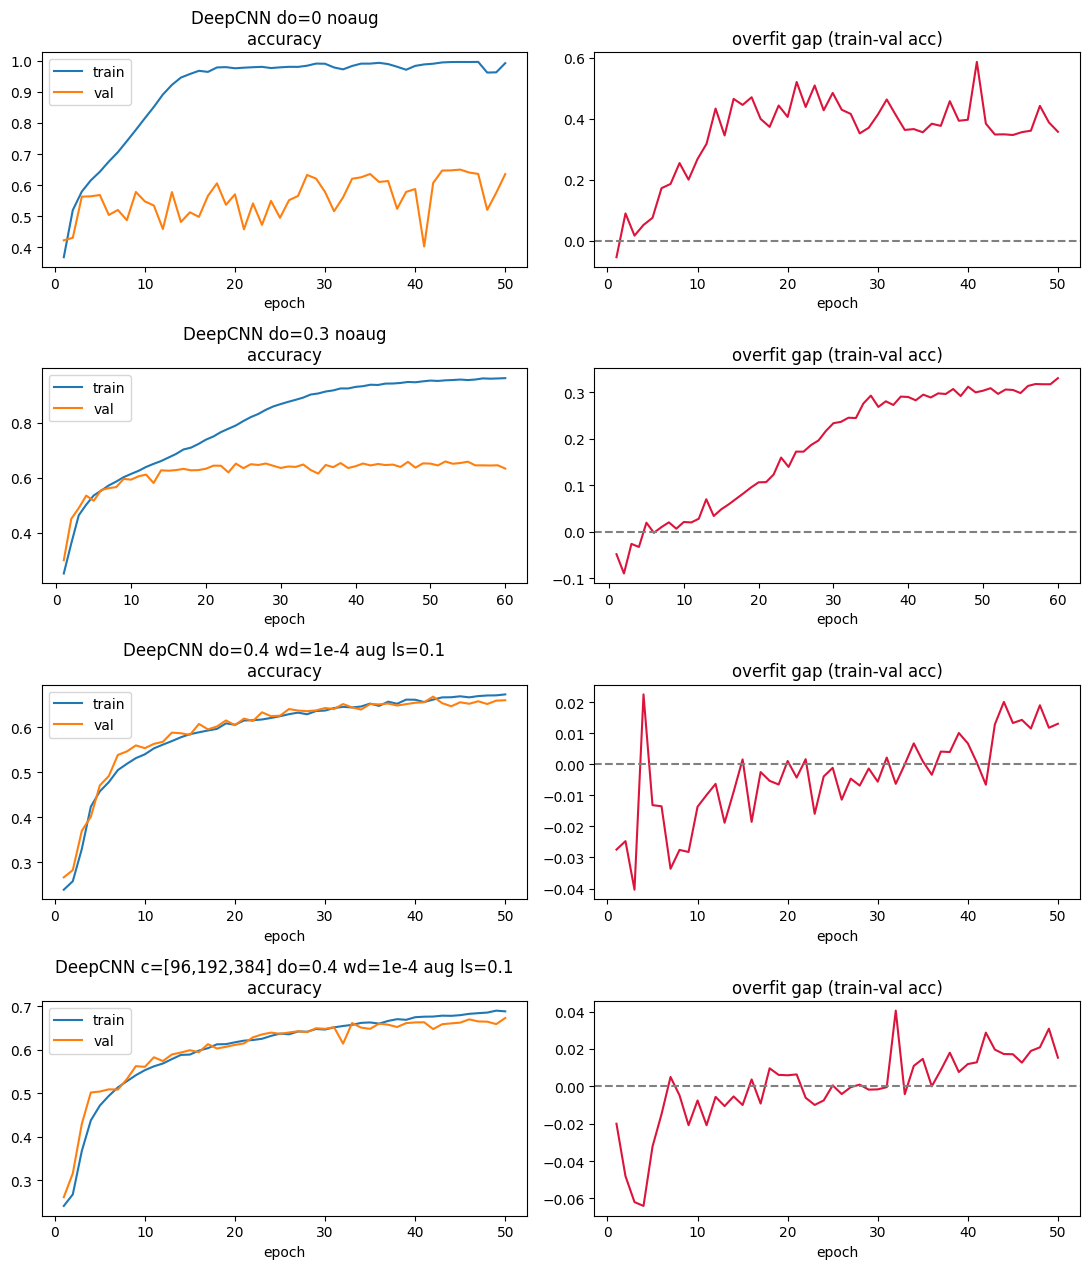

In [15]:
import matplotlib.pyplot as plt
n = len(HISTORY)
fig, axes = plt.subplots(n, 2, figsize=(11, 3.2 * n))
if n == 1: axes = axes.reshape(1, 2)
for row, (name, h) in zip(axes, HISTORY.items()):
    ep = range(1, len(h["train_acc"]) + 1)
    row[0].plot(ep, h["train_acc"], label="train")
    row[0].plot(ep, h["val_acc"], label="val")
    row[0].set_title(name + "\naccuracy"); row[0].set_xlabel("epoch"); row[0].legend()
    row[1].plot(ep, h["gap"], color="crimson"); row[1].axhline(0, ls="--", c="gray")
    row[1].set_title("overfit gap (train-val acc)"); row[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

,params,best_val_acc,test_acc,test_f1,final_gap
run,,,,,
DeepCNN do=0 noaug,1214151,0.6261,0.6339,0.6182,0.4700
DeepCNN do=0.3 noaug,1214151,0.6623,0.6826,0.6667,0.3080
DeepCNN do=0 noaug,1214151,0.6498,0.6431,0.6275,0.3576
DeepCNN do=0.3 noaug,1214151,0.6595,0.6748,0.6550,0.3301
DeepCNN do=0.4 wd=1e-4 aug ls=0.1,1214151,0.6679,0.6732,0.6297,0.0130
"DeepCNN c=[96,192,384] do=0.4 wd=1e-4 aug ls=0.1",2727463,0.6726,0.6849,0.6527,0.0153


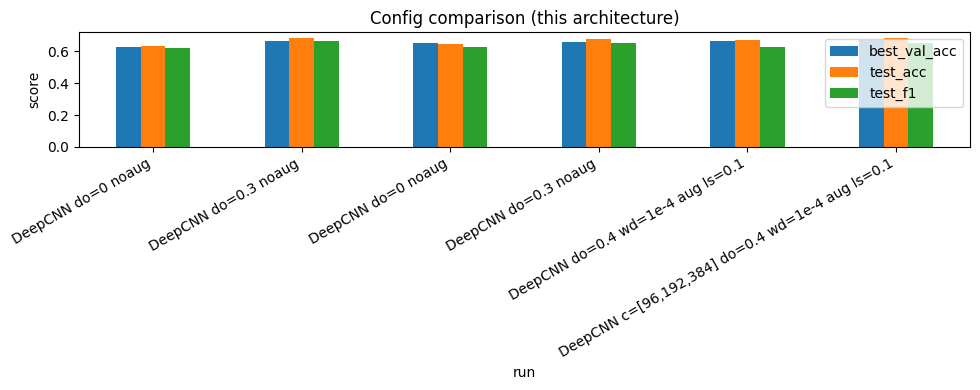

In [16]:
import pandas as pd
df = pd.DataFrame(SUMMARY).set_index("run")
display(df.round(4))
ax = df[["best_val_acc", "test_acc", "test_f1"]].plot(kind="bar", figsize=(10, 4))
ax.set_ylabel("score"); ax.set_title("Config comparison (this architecture)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

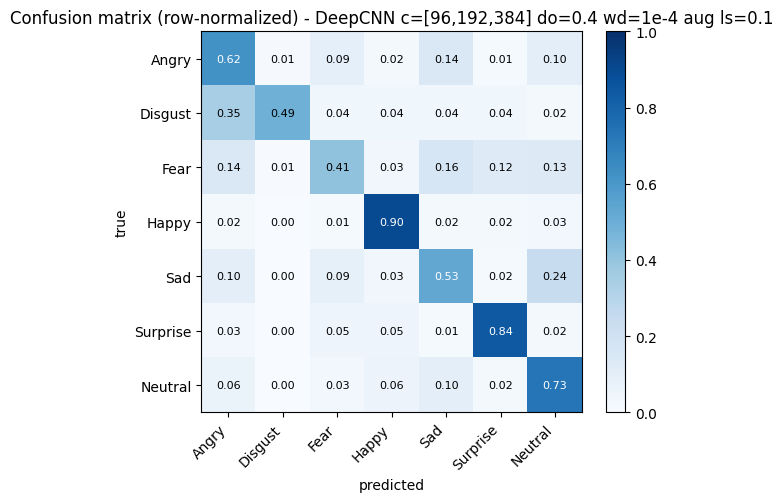

In [17]:
from sklearn.metrics import confusion_matrix
best = max(SUMMARY, key=lambda d: d["test_acc"])["run"]
yt, yp = CONF[best]
cm = confusion_matrix(yt, yp); cmn = cm / cm.sum(1, keepdims=True)
cls = [EMOTIONS[i] for i in range(NUM_CLASSES)]
fig, ax = plt.subplots(figsize=(6, 5)); im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(7)); ax.set_xticklabels(cls, rotation=45, ha="right")
ax.set_yticks(range(7)); ax.set_yticklabels(cls)
for i in range(7):
    for j in range(7):
        ax.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center",
                color="white" if cmn[i, j] > 0.5 else "black", fontsize=8)
ax.set_title("Confusion matrix (row-normalized) - " + best)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.colorbar(im); plt.tight_layout(); plt.show()

In [18]:
from sklearn.metrics import classification_report
import pandas as pd
yt, yp = CONF[best]
rep = classification_report(yt, yp, target_names=[EMOTIONS[i] for i in range(7)],
                            output_dict=True, zero_division=0)
display(pd.DataFrame(rep).T.round(3))

,precision,recall,f1-score,support
Angry,0.581,0.623,0.601,491.000
Disgust,0.730,0.491,0.587,55.000
Fear,0.592,0.407,0.483,528.000
Happy,0.881,0.895,0.888,879.000
Sad,0.565,0.529,0.546,594.000
Surprise,0.756,0.841,0.796,416.000
Neutral,0.612,0.733,0.667,626.000
accuracy,0.685,0.685,0.685,0.685
macro avg,0.674,0.646,0.653,3589.000
weighted avg,0.681,0.685,0.679,3589.000


## 9. Automated hyperparameter search - W&B Sweep


In [19]:

def sweep_train():
    with wandb.init(group=GROUP) as run:
        cfg = wandb.config
        run.name = (f"sweep lr={cfg.lr:.1e} do={cfg.dropout} "
                    f"wd={cfg.weight_decay:.0e} bs={cfg.batch_size} aug={cfg.augment}")
        tr, va, te = load_data(batch_size=cfg.batch_size, augment=cfg.augment)
        model = DeepCNN(channels=(64,128,256), fc=256, dropout=cfg.dropout).to(device)
        wandb.watch(model, log="all", log_freq=100)
        opt  = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
        crit = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
        best = 0.0
        for ep in range(1, cfg.epochs + 1):
            trl, tra = train_one_epoch(model, tr, opt, crit)
            val, vaa, vp, vt = evaluate(model, va, crit)
            wandb.log({"epoch":ep, "train/loss":trl, "train/acc":tra,
                       "val/loss":val, "val/acc":vaa, "overfit_gap":tra-vaa})
            best = max(best, vaa)
        wandb.run.summary["best_val_acc"] = best

In [20]:

sweep_config = {
    "method": "bayes",
    "metric": {"name": "val/acc", "goal": "maximize"},
    "parameters": {
        "lr":              {"distribution": "log_uniform_values", "min": 1e-4, "max": 1e-2},
        "weight_decay":    {"distribution": "log_uniform_values", "min": 1e-5, "max": 1e-3},
        "dropout":         {"values": [0.3, 0.4, 0.5]},
        "batch_size":      {"values": [64, 128]},
        "augment":         {"values": [True, False]},
        "label_smoothing": {"values": [0.0, 0.1]},
        "epochs":          {"value": 30},
    },
}
sweep_id = wandb.sweep(sweep_config, project=PROJECT)
print("sweep id:", sweep_id)
wandb.agent(sweep_id, function=sweep_train, count=6)

Create sweep with ID: xgqduxm6
Sweep URL: https://wandb.ai/rkvit23-free-university-of-tbilisi-/fer2013-emotion/sweeps/xgqduxm6
sweep id: xgqduxm6


wandb: Agent Starting Run: 7xulgza0 with config:
wandb: 	augment: False
wandb: 	batch_size: 128
wandb: 	dropout: 0.3
wandb: 	epochs: 30
wandb: 	label_smoothing: 0
wandb: 	lr: 0.0005385754509665589
wandb: 	weight_decay: 0.00097094890652899
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
overfit_gap,▁▂▂▃▃▃▃▃▃▃▄▃▃▄▄▄▅▄▅▅▅▅▅▆▆▆▇▇█▇
train/acc,▁▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇████
train/loss,█▇▆▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁
val/acc,▁▄▅▅▅▅▆▇▇▇▇▇▇▇▇▇▇███████▇███▇█
val/loss,█▆▄▅▃▃▃▂▂▂▂▁▂▂▂▁▂▁▁▁▁▁▁▁▂▂▂▂▃▂
best_val_acc,0.64698
epoch,30
overfit_gap,0.18085
train/acc,0.82782
train/loss,0.47694


wandb: Agent Starting Run: 63lte4wd with config:
wandb: 	augment: True
wandb: 	batch_size: 64
wandb: 	dropout: 0.4
wandb: 	epochs: 30
wandb: 	label_smoothing: 0
wandb: 	lr: 0.0019786657495664364
wandb: 	weight_decay: 8.295145549329156e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
overfit_gap,▆▅▁▅▇▅▇▆▅▇▆█▇▆▇▆▇▆▇▆▆▆▆▇▇█▇▇▇▇
train/acc,▁▂▃▅▅▆▆▆▇▇▇▇▇▇▇▇▇█████████████
train/loss,█▇▆▅▄▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▂▅▅▅▆▆▇▇▇▇▇▇▇▇█▇█████████████
val/loss,█▇▅▄▄▃▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▂▁▁▁▁
best_val_acc,0.62775
epoch,30
overfit_gap,-0.00662
train/acc,0.61193
train/loss,1.03474


...

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
overfit_gap,▆▁▂▄▅▆▄▆▇▆▅▆▅▆▇██▆▇▇█▆█▇█▇▇▇▆▇
train/acc,▁▂▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇███████████
train/loss,█▇▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val/acc,▁▃▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇███████
val/loss,█▆▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▂▁▂▁▁▁▁▁
best_val_acc,0.64168
epoch,30
overfit_gap,0.00034
train/acc,0.63311
train/loss,0.97126


wandb: Agent Starting Run: wp7rg6z1 with config:
wandb: 	augment: False
wandb: 	batch_size: 128
wandb: 	dropout: 0.3
wandb: 	epochs: 30
wandb: 	label_smoothing: 0.1
wandb: 	lr: 0.00013369057802829822
wandb: 	weight_decay: 0.0001274963824111088
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
overfit_gap,▂▁▂▃▄▅▄▄▆▅▅▅▅▅▆▆▆▆▇▆▇▇▇▇█▇▇▇██
train/acc,▁▂▃▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇███████
train/loss,█▇▆▅▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
val/acc,▁▃▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇█▇█████████
val/loss,█▆▅▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▂▁▁▁▁▁
best_val_acc,0.62914
epoch,30
overfit_gap,0.05583
train/acc,0.67913
train/loss,1.1163


wandb: Agent Starting Run: ozpmfyoc with config:
wandb: 	augment: True
wandb: 	batch_size: 128
wandb: 	dropout: 0.3
wandb: 	epochs: 30
wandb: 	label_smoothing: 0
wandb: 	lr: 0.0005498285812153874
wandb: 	weight_decay: 1.179226802708266e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
overfit_gap,▆▁▅▆▆▆▇▇▆▅▆▆▇▆▆▇▇▆▇▇▆▇█▇██▇█▇▇
train/acc,▁▂▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█████████
train/loss,█▇▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val/acc,▁▄▄▅▅▆▆▆▇▇▇▇▇▇▇▇▇█▇██▇▇███████
val/loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▂▂▁▁▂▁▁▁▁
best_val_acc,0.63667
epoch,30
overfit_gap,0.00411
train/acc,0.63994
train/loss,0.9482
